In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

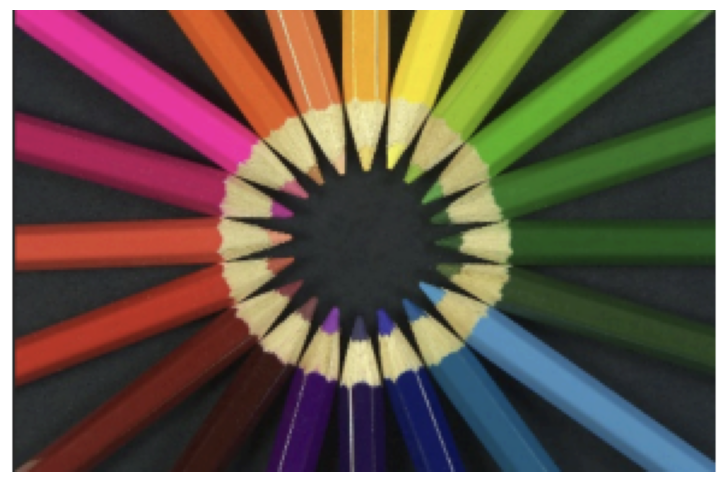

In [46]:
img = cv2.imread("./pics/red4.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#show
plt.figure(figsize=(15,6))
plt.imshow(img)
plt.axis('off')
plt.show()

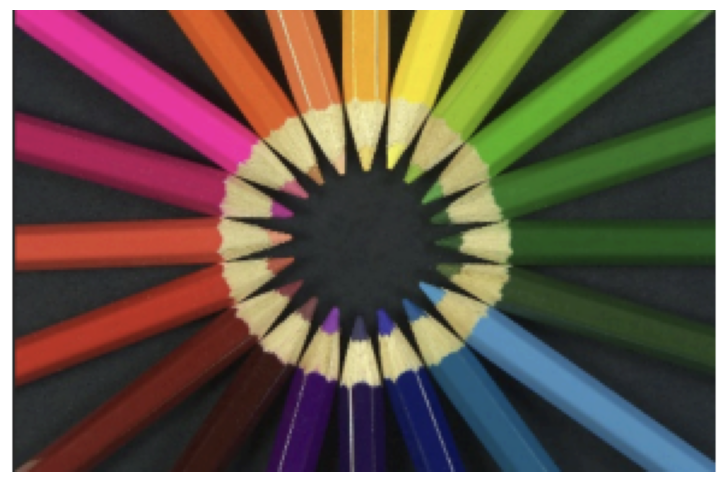

In [47]:
#Preprocessing
img_blur = cv2.GaussianBlur(img, (7, 7), 0)
#show
plt.figure(figsize=(15,6))
plt.imshow(img)
plt.axis('off')
plt.show()

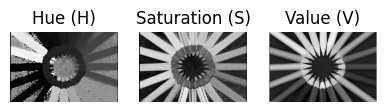

In [48]:
#hsv mask
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
H, S, V = cv2.split(hsv)

#SHOW
plt.subplot(1,4,2)
plt.imshow(H, cmap='gray')
plt.title("Hue (H)")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(S, cmap='gray')
plt.title("Saturation (S)")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(V, cmap='gray')
plt.title("Value (V)")
plt.axis("off")

plt.show()



In [49]:
# Lower red range
lower_red1 = np.array([0, 150, 90])
upper_red1 = np.array([6, 255, 255])

# Upper red range
lower_red2 = np.array([174, 150, 90])
upper_red2 = np.array([179, 255, 255])

# Create masks
mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)


In [50]:
#Oring
# Combine masks
red_mask = mask1 | mask2

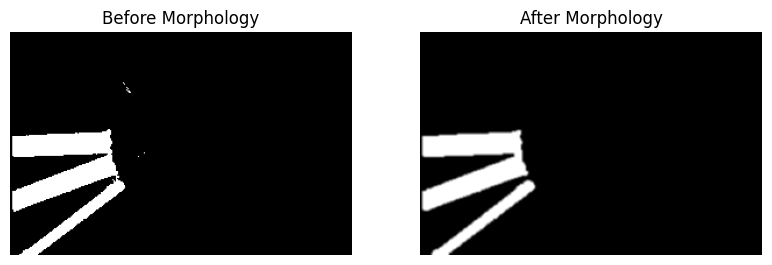

In [51]:
#Step 3 — Morphological cleaning
kernel = np.ones((3,3), np.uint8)

mask_clean = cv2.morphologyEx(red_mask, cv2.MORPH_OPEN, kernel)   # remove tiny dots
mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel) # fill holes
mask_clean = cv2.GaussianBlur(mask_clean, (3,3), 0)          # smooth edges


#show
plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.title("Before Morphology"); plt.imshow(red_mask, cmap='gray'); plt.axis('off')

plt.subplot(1,3,2); plt.title("After Morphology"); plt.imshow(mask_clean, cmap='gray'); plt.axis('off')
plt.show()


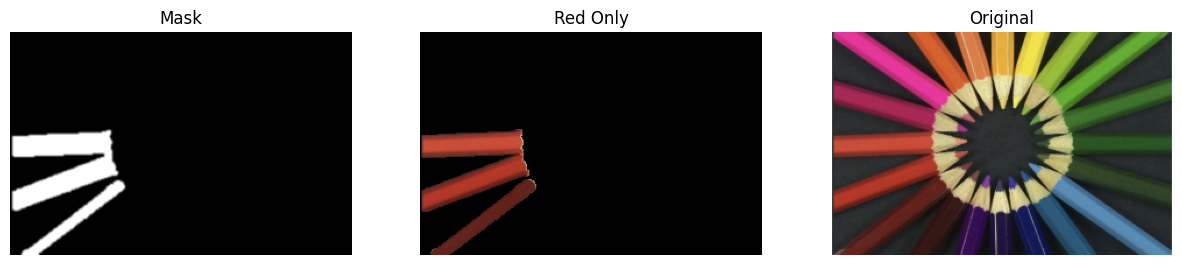

: 

In [ ]:
# Apply mask
red_only = cv2.bitwise_and(img, img, mask=mask_clean)

# Show
plt.figure(figsize=(15,6))
plt.subplot(1,3,1); plt.title("Mask"); plt.imshow(mask_clean, cmap='gray'); plt.axis('off')
plt.subplot(1,3,2); plt.title("Red Only"); plt.imshow(red_only); plt.axis('off')
plt.subplot(1,3,3); plt.title("Original"); plt.imshow(img); plt.axis('off')
plt.show()
